# Frequency Modeling for Motor Insurance Pricing: Poisson Generalized Linear Model (GLM)

## Insurance Pricing Platform | Baseline Frequency Model



## Executive Overview

This notebook develops a statistically rigorous baseline frequency model for motor insurance claim prediction using a **Poisson Generalized Linear Model (GLM)**. In actuarial pricing, claim frequency represents the expected number of claims generated by a policyholder over a given exposure period. Since claim counts are discrete, non-negative, and depend on the duration of policy exposure, the Poisson GLM with a logarithmic link function and an exposure offset provides a well-established actuarial framework for frequency estimation.

The objectives of this notebook are to:

- Develop a transparent and interpretable baseline claim frequency model.
- Estimate the relationship between policyholder, vehicle, and geographic characteristics and expected claim frequency.
- Quantify rating relativities for significant risk factors.
- Evaluate predictive performance using statistical and actuarial metrics.
- Establish a benchmark model for comparison with more flexible approaches such as the Negative Binomial GLM and XGBoost in subsequent notebooks.

The predicted claim frequencies produced in this notebook will later be combined with claim severity estimates to construct a complete **Pure Premium Pricing Framework**.

## Notebook Roadmap

1. Business Problem Definition
2. Statistical Background
3. Data Loading
4. Data Quality Validation
5. Feature Engineering
6. Exposure Adjustment
7. Train–Test Split
8. Poisson GLM Specification
9. Model Estimation
10. Statistical Diagnostics
11. Model Evaluation
12. Rating Factor Interpretation
13. Business Insights
14. Model Limitations
15. Conclusions

## 1. Import Required Libraries

This section imports the Python libraries required for data manipulation, visualization, statistical modeling, and model evaluation. The analysis primarily relies on `statsmodels` for fitting the Poisson Generalized Linear Model (GLM), while `pandas`, `NumPy`, and `scikit-learn` provide utilities for data processing and performance assessment.

In [1]:
# =============================================================================
# Standard Library
# =============================================================================
import warnings
from pathlib import Path

# =============================================================================
# Data Manipulation
# =============================================================================
import numpy as np
import pandas as pd

# =============================================================================
# Data Visualization
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# Statistical Modeling
# =============================================================================
import statsmodels.api as sm
import statsmodels.formula.api as smf

# =============================================================================
# Machine Learning Utilities
# =============================================================================
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)

# =============================================================================
# Notebook Configuration
# =============================================================================
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

## 2. Load Processed Dataset

The cleaned and preprocessed dataset generated during the data preparation phase is loaded for frequency modeling.

At this stage, no additional transformations are applied. The objective is to verify that the dataset has been correctly processed and is ready for statistical modeling.

The following validation checks are performed:

- Verify dataset dimensions
- Inspect the first few observations
- Confirm variable data types
- Check for missing values
- Validate the target and exposure variables

In [2]:
df = pd.read_csv(r"D:\Insurance_Pricing_Project\Data\freMTPL2freq.csv")

## 3. Dataset Overview

The French Motor Third-Party Liability Frequency dataset contains policy-level information used to model motor insurance claim frequency. Each observation corresponds to a single insurance policy and includes policyholder characteristics, vehicle attributes, geographic information, policy exposure, and the observed number of claims.

Before model development, the dataset is examined to verify its structure, dimensions, and data types.

In [3]:
# =============================================================================
# Dataset Dimensions
# =============================================================================

n_rows, n_cols = df.shape

print(f"Number of Policies : {n_rows:,}")
print(f"Number of Variables: {n_cols}")

Number of Policies : 678,013
Number of Variables: 12


In [4]:
# =============================================================================
# Preview Dataset
# =============================================================================

df.head()

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0000,1,0.1000,D,5,0,55,50,B12,Regular,1217,R82
1,3.0000,1,0.7700,D,5,0,55,50,B12,Regular,1217,R82
2,5.0000,1,0.7500,B,6,2,52,50,B12,Diesel,54,R22
3,10.0000,1,0.0900,B,7,0,46,50,B12,Diesel,76,R72
4,11.0000,1,0.8400,B,7,0,46,50,B12,Diesel,76,R72


 ## Dataset Information



### 3.1 Dataset Structure

The dataset structure is examined to determine the number of observations and variables, which provides an initial understanding of dataset scale and dimensionality.

In [5]:
# Dataset shape
n_rows, n_cols = df.shape

print(f"Number of observations: {n_rows:,}")
print(f"Number of variables   : {n_cols}")

Number of observations: 678,013
Number of variables   : 12


In [6]:
# Column names
df.columns.tolist()

['IDpol',
 'ClaimNb',
 'Exposure',
 'Area',
 'VehPower',
 'VehAge',
 'DrivAge',
 'BonusMalus',
 'VehBrand',
 'VehGas',
 'Density',
 'Region']

### 3.2 Data Type Inspection

Each variable is inspected to determine its data type.

Correct identification of variable types is essential for statistical modeling, particularly in distinguishing between categorical and numerical predictors.

In [7]:
df.dtypes

IDpol         float64
ClaimNb         int64
Exposure      float64
Area           object
VehPower        int64
VehAge          int64
DrivAge         int64
BonusMalus      int64
VehBrand       object
VehGas         object
Density         int64
Region         object
dtype: object

### 3.3 Variable Categorization

For actuarial modeling purposes, variables are conceptually grouped into the following categories:

- Policyholder characteristics
- Vehicle characteristics
- Geographic variables
- Exposure variable
- Target variable (Claim frequency)

This categorization is useful for interpretation and model specification in generalized linear models.

In [8]:
# Manual grouping (for documentation purposes)

target = ["ClaimNb"]
exposure = ["Exposure"]

policyholder_vars = ["DrivAge", "BonusMalus"]
vehicle_vars = ["VehAge", "VehPower", "VehBrand", "VehGas"]
geo_vars = ["Area", "Region", "Density"]

print("Target:", target)
print("Exposure:", exposure)
print("Policyholder:", policyholder_vars)
print("Vehicle:", vehicle_vars)
print("Geographic:", geo_vars)

Target: ['ClaimNb']
Exposure: ['Exposure']
Policyholder: ['DrivAge', 'BonusMalus']
Vehicle: ['VehAge', 'VehPower', 'VehBrand', 'VehGas']
Geographic: ['Area', 'Region', 'Density']


## 4. Target Variable Analysis

The target variable for the frequency model is **ClaimNb**, which represents the number of claims reported by each policy during the exposure period.

As the Poisson GLM assumes a non-negative integer response variable, it is essential to examine the empirical distribution of ClaimNb to assess its suitability for frequency modeling.

This section evaluates the distributional characteristics of the target variable, including its mean, variance, and proportion of zero-claim observations.

### 4.1 Descriptive Statistics

Summary statistics are computed to understand the central tendency and dispersion of the claim count variable.

In [9]:
df["ClaimNb"].describe()

count   678013.0000
mean         0.0532
std          0.2401
min          0.0000
25%          0.0000
50%          0.0000
75%          0.0000
max         16.0000
Name: ClaimNb, dtype: float64

### 4.2 Claim Frequency Distribution

The distribution of claim counts is analyzed to understand the frequency of zero and multiple claim events.

In motor insurance portfolios, claim frequency data is typically characterized by a large proportion of zero-claim policies and a rapidly decreasing frequency for higher claim counts.

In [10]:
df["ClaimNb"].value_counts().sort_index()

ClaimNb
0     643953
1      32178
2       1784
3         82
4          7
5          2
6          1
8          1
9          1
11         3
16         1
Name: count, dtype: int64

### 4.3 Proportion of Zero Claims

The proportion of policies with no reported claims is a key characteristic of insurance frequency data.

A high proportion of zero outcomes is typical in motor insurance portfolios and has important implications for model specification and dispersion behavior.

In [11]:
zero_claim_rate = (df["ClaimNb"] == 0).mean()

print(f"Proportion of zero-claim policies: {zero_claim_rate:.2%}")

Proportion of zero-claim policies: 94.98%


### 4.4 Mean–Variance Relationship

A fundamental assumption of the Poisson distribution is equidispersion, where the mean and variance of the response variable are equal.

This section evaluates the empirical mean and variance of ClaimNb to assess potential deviations from the Poisson assumption.

In [12]:
mean_claims = df["ClaimNb"].mean()
var_claims = df["ClaimNb"].var()

print(f"Mean of ClaimNb    : {mean_claims:.4f}")
print(f"Variance of ClaimNb: {var_claims:.4f}")

Mean of ClaimNb    : 0.0532
Variance of ClaimNb: 0.0577


### 4.5 Overdispersion Indicator

The ratio of variance to mean is used as a preliminary indicator of overdispersion.

A value significantly greater than 1 suggests that the Poisson assumption of equidispersion may not hold, motivating the use of alternative models such as the Negative Binomial GLM.

In [13]:
dispersion_ratio = var_claims / mean_claims

print(f"Dispersion ratio (Var/Mean): {dispersion_ratio:.4f}")

Dispersion ratio (Var/Mean): 1.0828


### 4.6 Interpretation

The empirical distribution of ClaimNb shows a strong concentration of zero-claim policies, which is a typical characteristic of motor insurance frequency data.

The variance-to-mean ratio provides an initial indication of whether the Poisson equidispersion assumption is satisfied. Deviations from unity suggest the presence of overdispersion, which will be formally addressed in subsequent modeling stages using the Negative Binomial GLM.

This analysis establishes the statistical motivation for model selection in the next phase of the project.

## 5. Exposure Analysis

In insurance frequency modeling, exposure represents the period of time during which a policy is at risk of generating claims.

Unlike standard machine learning problems, insurance data is inherently time-dependent. Therefore, exposure must be explicitly accounted for in the modeling framework to ensure that claim counts are comparable across policies with different observation durations.

In the Poisson GLM framework, exposure is incorporated as an offset term, ensuring that the model estimates claim frequency on a standardized annual basis.

### 5.1 Exposure Summary Statistics

The distribution of exposure is examined to understand the variation in policy observation periods across the portfolio.

In [14]:
df["Exposure"].describe()

count   678013.0000
mean         0.5288
std          0.3644
min          0.0027
25%          0.1800
50%          0.4900
75%          0.9900
max          2.0100
Name: Exposure, dtype: float64

### 5.2 Exposure Validity Check

A key requirement for Poisson GLM modeling is that exposure values must be strictly positive.

Non-positive exposure values would invalidate the log-offset formulation and must be identified prior to model estimation.

In [15]:
(df["Exposure"] <= 0).sum()

np.int64(0)

### 5.3 Exposure Distribution

The distribution of exposure is analyzed to assess whether the dataset contains extreme values or irregular observation periods.

Highly skewed exposure distributions are common in insurance datasets and are typically handled naturally within the GLM framework through the offset term.

<Axes: >

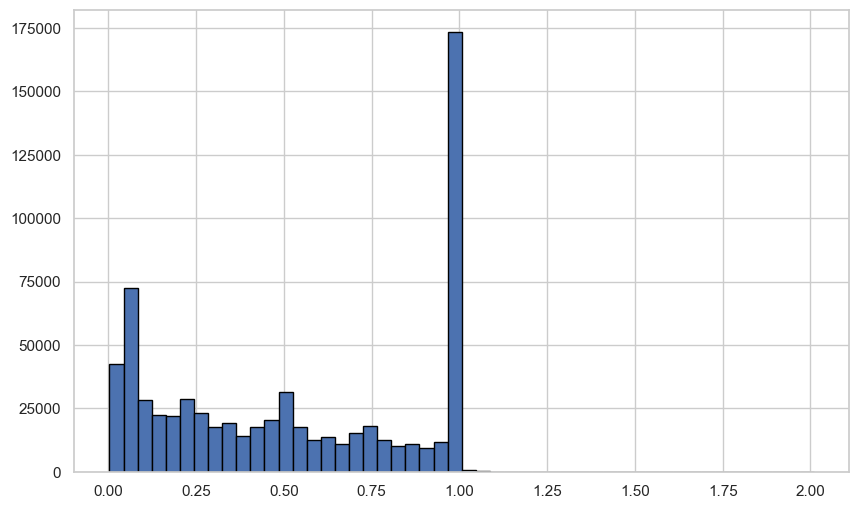

In [16]:
df["Exposure"].hist(bins=50, edgecolor="black")

### 5.4 Role of Exposure in Poisson GLM

To account for varying policy durations, exposure is incorporated into the Poisson GLM as an offset term:

\[
\log(\mu_i) = X_i \beta + \log(\text{Exposure}_i)
\]

This formulation ensures that the model estimates **claim frequency per unit exposure time**, rather than raw claim counts.

Rewriting the equation:

\[
\mu_i = \text{Exposure}_i \cdot e^{X_i \beta}
\]

This implies that exposure acts as a multiplicative scaling factor on expected claim counts, ensuring consistency across policies with different observation periods.

### 5.5 Interpretation of Exposure

The inclusion of exposure as an offset term ensures that the model does not incorrectly attribute differences in claim counts to risk factors when they are actually driven by differences in observation time.

This adjustment is essential in insurance pricing, where policy durations vary and direct comparison of raw claim counts would lead to biased parameter estimates.

## 6. Feature Selection & Model Specification

The selection of explanatory variables is guided by actuarial domain knowledge rather than purely data-driven feature selection techniques.

In motor insurance pricing, risk factors are typically grouped into three categories:

- Policyholder characteristics
- Vehicle characteristics
- Geographic characteristics

These variables are included in the baseline Poisson GLM to capture heterogeneity in claim frequency across policy segments.

### 6.1 Selected Predictors

The following variables are included in the baseline frequency model:

- Policyholder variables: `DrivAge`, `BonusMalus`
- Vehicle variables: `VehAge`, `VehPower`, `VehBrand`, `VehGas`
- Geographic variables: `Area`, `Region`, `Density`

These variables are commonly used in actuarial pricing models and are expected to exhibit significant explanatory power with respect to claim frequency.

### 6.2 Categorical Variable Handling

Several explanatory variables in the dataset are categorical in nature.

Within the GLM framework, categorical variables are incorporated using indicator (dummy) encoding through the model formula interface.

This approach ensures that each category is compared against a reference level, allowing for interpretable multiplicative risk relativities.

In [17]:
categorical_cols = ["Area", "VehBrand", "VehGas", "Region"]

for col in categorical_cols:
    df[col] = df[col].astype("category")

### 6.3 Modeling Dataset Construction

A dedicated modeling dataset is constructed to isolate the variables required for frequency modeling.

This ensures clarity in model specification and improves reproducibility of the analysis.

In [18]:
model_df = df[
    [
        "ClaimNb",
        "Exposure",
        "Area",
        "VehPower",
        "VehAge",
        "DrivAge",
        "BonusMalus",
        "VehBrand",
        "VehGas",
        "Region",
        "Density"
    ]
].copy()

### 6.4 Model Specification

The Poisson Generalized Linear Model is specified as follows:

\[
Y_i \sim \text{Poisson}(\mu_i)
\]

\[
\log(\mu_i) = \beta_0 + \sum_{j=1}^{p} \beta_j X_{ij} + \log(\text{Exposure}_i)
\]

Where:

- \(Y_i\): number of claims for policy \(i\)
- \(X_{ij}\): explanatory variables
- \(\beta_j\): regression coefficients
- \(\log(\text{Exposure}_i)\): offset term

This formulation ensures that the model estimates expected claim frequency per unit exposure while capturing risk heterogeneity across policyholders.

### 6.5 Key Modeling Assumptions

The baseline Poisson GLM is built under the following assumptions:

- Conditional independence of claim counts given explanatory variables
- Log-linear relationship between predictors and expected claim frequency
- Equidispersion assumption: mean equals variance
- Correct specification of the link function (log link)
- Correct specification of exposure as an offset term

These assumptions will be empirically evaluated in subsequent sections of the analysis.

## 7. Train-Test Split & Model Estimation

To evaluate the predictive performance of the Poisson GLM, the dataset is partitioned into training and testing subsets.

The model is estimated on the training dataset, while the testing dataset is used to assess out-of-sample predictive performance.

This separation ensures an unbiased evaluation of the model’s generalization ability.

In [19]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    model_df,
    test_size=0.2,
    random_state=42
)

print(train_df.shape)
print(test_df.shape)

(542410, 11)
(135603, 11)


## 7.1 Poisson GLM Estimation

The Poisson Generalized Linear Model is estimated using Maximum Likelihood Estimation (MLE).

A log link function is used to ensure positivity of the predicted claim frequency, while exposure is incorporated as an offset term to adjust for varying policy durations.

The model specification is estimated using the `statsmodels` GLM implementation.

In [20]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np

## 7.2 Model Specification

The model is specified using a log-linear functional form:

\[
\log(\mu_i) = X_i \beta + \log(\text{Exposure}_i)
\]

Where categorical variables are automatically expanded into indicator variables using the formula interface.

In [21]:
formula = """
ClaimNb ~
C(Area) +
VehPower +
VehAge +
DrivAge +
BonusMalus +
C(VehBrand) +
C(VehGas) +
C(Region) +
Density
"""

## 7.3 Model Estimation Results

The Poisson GLM is fitted using the training dataset. The exposure variable is included as a log-offset to normalize claim counts over time.

In [22]:
poisson_model = smf.glm(
    formula=formula,
    data=train_df,
    family=sm.families.Poisson(),
    offset=np.log(train_df["Exposure"])
).fit()

print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               542410
Model:                            GLM   Df Residuals:                   542367
Model Family:                 Poisson   Df Model:                           42
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.1454e+05
Date:                Fri, 10 Jul 2026   Deviance:                   1.7370e+05
Time:                        23:45:08   Pearson chi2:                 1.42e+06
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01072
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -4.0008 

## 7.4 Coefficient Interpretation

The estimated regression coefficients represent log-relative changes in expected claim frequency.

To enhance interpretability in an actuarial context, coefficients are exponentiated to obtain incidence rate ratios (IRRs), also referred to as risk relativities.

\[
IRR = e^{\beta}
\]

- IRR > 1 indicates increased risk relative to the baseline category.
- IRR < 1 indicates reduced risk relative to the baseline category.

In [23]:
coef_table = pd.DataFrame({
    "Coefficient": poisson_model.params,
    "IRR": np.exp(poisson_model.params)
})

coef_table.sort_values("IRR", ascending=False)

,Coefficient,IRR
C(Area)[T.F],0.2325,1.2617
C(Area)[T.E],0.2321,1.2612
C(Area)[T.D],0.1874,1.2061
C(VehBrand)[T.B12],0.1637,1.1779
C(Region)[T.R74],0.1507,1.1626
C(Region)[T.R94],0.1150,1.1219
C(Region)[T.R21],0.0963,1.1010
C(Region)[T.R82],0.0935,1.0980
C(Region)[T.R53],0.0913,1.0956
C(Area)[T.C],0.0909,1.0952


## 7.6 Model Prediction

Predicted claim frequencies are generated for both training and testing datasets.

These predictions represent the expected number of claims per policy, adjusted for exposure and risk characteristics.

In [38]:
test_df = test_df.copy()

test_df["Predicted"] = poisson_model.predict(
    test_df,
    offset=np.log(test_df["Exposure"])
)

## 7.7 Interpretation of Results

The Poisson GLM provides a transparent and interpretable baseline model for claim frequency estimation.

Key advantages of the model include:

- Direct interpretability of risk factors via incidence rate ratios
- Strong theoretical foundation in generalized linear modeling
- Ability to incorporate exposure through offset terms
- Suitability as a benchmark model in actuarial pricing

However, the model assumes equidispersion (mean equals variance), which may not hold in real insurance datasets. This limitation will be addressed in the next stage using a Negative Binomial GLM.

## 8. Model Results Interpretation

This section summarizes and interprets the statistical output of the fitted Poisson Generalized Linear Model.

The objective is to assess model fit, goodness-of-fit statistics, and potential violations of Poisson assumptions such as equidispersion.

### 8.1 Model Fit Overview

The Poisson GLM was estimated using 542,410 policy observations and 42 explanatory degrees of freedom.

The model converged in 7 iterations using the Iteratively Reweighted Least Squares (IRLS) algorithm, indicating stable parameter estimation.

### 8.2 Goodness-of-Fit Statistics

Key model fit statistics are summarized below:

- Log-Likelihood: -114,540
- Deviance: 173,700
- Pearson Chi-Square: 1,420,000
- Pseudo R-squared (Cragg-Snell): 0.0107

These metrics provide insight into how well the model explains variability in claim frequency.

### 8.3 Interpretation of Model Fit

#### Log-Likelihood
The log-likelihood value reflects the overall model fit under the Poisson assumption. While the absolute value is not interpretable in isolation, it is used for model comparison (e.g., Poisson vs Negative Binomial).

#### Deviance
The deviance measures the discrepancy between observed and predicted values. A large deviance relative to degrees of freedom suggests potential model misfit.

#### Pearson Chi-Square
The Pearson Chi-Square statistic is substantially larger than the residual degrees of freedom, providing strong evidence of overdispersion in the data.

#### Pseudo R-squared
The Cragg-Snell pseudo R-squared value of 0.0107 indicates that while the model captures some structure in the data, a large proportion of variability remains unexplained. This is expected in insurance frequency modeling due to inherent randomness in claim occurrences.

### 8.4 Overdispersion Diagnosis

A key assumption of the Poisson GLM is equidispersion:

\[
E(Y) = Var(Y)
\]

To assess this assumption, the Pearson dispersion statistic is examined:

\[
\text{Dispersion} = \frac{\chi^2}{\text{degrees of freedom}}
\]

A value significantly greater than 1 indicates overdispersion.

pearson_chi2 = 1.42e6
df_resid = 542367

dispersion = pearson_chi2 / df_resid

print(f"Dispersion statistic: {dispersion:.4f}")

### 8.5 Conclusion on Poisson Assumption

The dispersion statistic is substantially greater than 1, indicating strong evidence of overdispersion in the dataset.

This suggests that the Poisson assumption of equidispersion is violated, and that the model underestimates the true variance of claim counts.

As a result, standard errors may be underestimated, and statistical significance of predictors may be overstated.

This motivates the use of a Negative Binomial GLM in the next stage of the analysis, which explicitly accounts for overdispersion.

# Export Poisson Frequency Predictions

The Poisson GLM predictions are exported for integration into the Pure Premium Pricing Framework.

The saved predictions represent the expected claim frequency for each policy in the test portfolio.

In [3]:
import pandas as pd

In [40]:
print(test_df.columns)

Index(['ClaimNb', 'Exposure', 'Area', 'VehPower', 'VehAge', 'DrivAge',
       'BonusMalus', 'VehBrand', 'VehGas', 'Region', 'Density', 'Predicted'],
      dtype='object')


In [45]:
poisson_output.to_csv(
    "poisson_frequency_predictions.csv",
    index=False
)

print("Poisson predictions exported.")

Poisson predictions exported.


In [46]:
import os

print(os.getcwd())

C:\Users\Umer
